# 05 — Descriptive Statistics & Survival Curves

**Author:** Ricardo Sanchez  

**Project:** Monetary Policy Shocks and Startup Funding Transitions (Seed → Series A)

**Date:** March 03, 2026 

**Data Source:** Cleaned survival datasets from notebooks 02 and 03 | Monetary policy shock series

---

## Objective

Produce descriptive statistics and Kaplan-Meier survival curves that characterize the Seed-to-Series A transition before any hazard modeling. These visualizations establish the baseline patterns in the data — overall transition rates, cross-sector differences, geographic heterogeneity, and sensitivity to macro regimes — and motivate the model specifications in `06_discrete_time_hazard_analysis.ipynb`.

## Inputs
- `data/cleaned/cleaned_fintech/fintech_simple_survival.csv`
- `data/cleaned/cleaned_ai/ai_simple_survival.csv`
- `data/raw/macro/monitary_shock.csv`

## Outputs
- Summary statistics tables (inline)
- Kaplan-Meier plots (inline)

---

**References**
- [lifelines Documentation](https://lifelines.readthedocs.io/en/latest/Quickstart.html#)
- [Kaplan-Meier, Nelson-Aalen & Parametric Models](https://lifelines.readthedocs.io/en/latest/Quickstart.html#kaplan-meier-nelson-aalen-and-parametric-models)

---

## Part 1 — Setup & Dependencies

### Install `lifelines`

The `lifelines` package provides the `KaplanMeierFitter` and `logrank_test` used throughout this notebook. The uninstall-then-reinstall pattern below resolves a known dependency conflict between `lifelines`, `formulaic`, and `narwhals`.

In [ ]:
# Was throwing errors on install for lifelines. This was solution found online
%pip uninstall -y lifelines formulaic narwhals 

# lifelines will pull in compatible formulaic + narwhals
%pip install lifelines

In [2]:
import pandas as pd
import numpy as np
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ── Plot style ──
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
COLORS = {"FinTech": "#1b9e77", "AI": "#d95f02"}

# Load cleaned FinTech survival dataset
simple_surv_ft = pd.read_csv(r"..\data\cleaned\cleaned_fintech\fintech_simple_survival.csv")

# Load cleaned AI survival dataset
simple_surv_ai = pd.read_csv(r"..\data\cleaned\cleaned_ai\ai_simple_survival.csv")

# Combine into a single cross-sector dataset for pooled analyses
surv = pd.concat([simple_surv_ft, simple_surv_ai], ignore_index=True)


---

## Part 2 — Summary Statistics

Before any visualization, summarize the key quantities that define the survival analysis: sample size, event rates, survival times, and covariate distributions — broken out by sector.

In [3]:
# ── Summary statistics by sector ──
def sector_stats(df, label):
    """Compute key descriptive statistics for a sector's survival dataset."""
    n = len(df)
    n_event = df["event_series_a"].sum()
    amounts = pd.to_numeric(
        df["seed_amount_usd"].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False),
        errors="coerce"
    )
    return {
        "Sector": label,
        "N firms": n,
        "Series A events": int(n_event),
        "Event rate (%)": round(n_event / n * 100, 1),
        "Median time to event (months)": round(df.loc[df["event_series_a"] == 1, "time_to_series_a_months"].median(), 1),
        "Median seed amount ($)": f"${amounts.median():,.0f}",
        "Mean seed amount ($)": f"${amounts.mean():,.0f}",
    }

stats = pd.DataFrame([
    sector_stats(simple_surv_ft, "FinTech"),
    sector_stats(simple_surv_ai, "AI"),
    sector_stats(surv, "Combined"),
]).set_index("Sector")

print(stats.to_string())

          N firms  Series A events  Event rate (%)  Median time to event (months) Median seed amount ($) Mean seed amount ($)
Sector                                                                                                                       
FinTech      1030              365            35.4                           16.6             $2,800,000           $3,748,908
AI           1173              409            34.9                           17.7             $2,800,000           $3,616,920
Combined     2203              774            35.1                           17.1             $2,800,000           $3,678,630


In [4]:
# ── Metro region breakdown (combined dataset) ──
metro_stats = (
    surv.groupby("metro_region")
    .agg(
        n_firms=("event_series_a", "size"),
        n_events=("event_series_a", "sum"),
        median_months=("time_to_series_a_months", "median"),
    )
    .assign(event_rate=lambda x: (x["n_events"] / x["n_firms"] * 100).round(1))
    .sort_values("n_firms", ascending=False)
)
print("── Event rates by metro region ──")
print(metro_stats.to_string())

── Event rates by metro region ──
              n_firms  n_events  median_months  event_rate
metro_region                                              
SFBA             1150       446      28.745072        38.8
GNYA              715       238      30.551905        33.3
GLA               234        64      36.580158        27.4
GMA               104        26      29.664915        25.0


In [5]:
# ── Cohort year breakdown (combined dataset) ──
surv["seed_year"] = pd.to_datetime(surv["seed_date"]).dt.year

cohort_stats = (
    surv.groupby("seed_year")
    .agg(
        n_firms=("event_series_a", "size"),
        n_events=("event_series_a", "sum"),
        median_months=("time_to_series_a_months", "median"),
    )
    .assign(event_rate=lambda x: (x["n_events"] / x["n_firms"] * 100).round(1))
)
print("── Event rates by seed cohort year ──")
print(cohort_stats.to_string())

── Event rates by seed cohort year ──
           n_firms  n_events  median_months  event_rate
seed_year                                              
2016           206       109      69.530223        52.9
2017           210        91      85.528909        43.3
2018           232       109      74.162286        47.0
2019           220        96      60.676741        43.6
2020           255       132      42.378449        51.8
2021           348       121      38.584100        34.8
2022           297        57      29.007884        19.2
2023           234        47      17.132063        20.1
2024           201        12       6.176084         6.0


---

## Part 3 — Overall Kaplan-Meier Curves

### 3.1 FinTech — All Startups

The cumulative density function shows the probability that a startup **has** transitioned to Series A by a given time. The complement (1 minus this curve) is the traditional survival function — the probability of remaining at Seed stage.

In [6]:
# Initialize the Kaplan-Meier estimator (reused across all fits below)
kmf = KaplanMeierFitter()

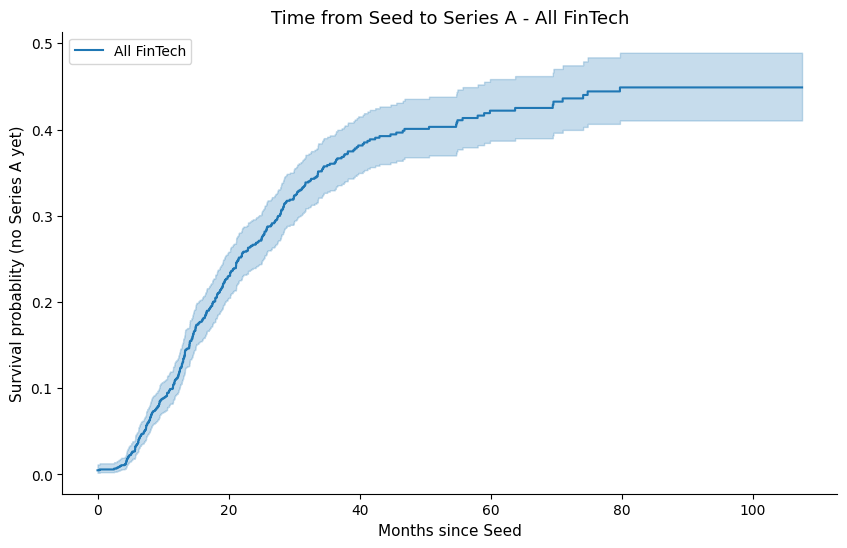

In [7]:
# Fit KM estimator on all FinTech startups (pooled across metros and cohorts)
kmf.fit(
    durations=simple_surv_ft["time_to_series_a_months"],
    event_observed=simple_surv_ft["event_series_a"],
    label="All FinTech"
)

kmf.plot_cumulative_density()
plt.xlabel("Months since Seed")
plt.ylabel("Survival probablity (no Series A yet)")
plt.title("Time from Seed to Series A - All FinTech")
plt.show()

### 3.2 AI — All Startups

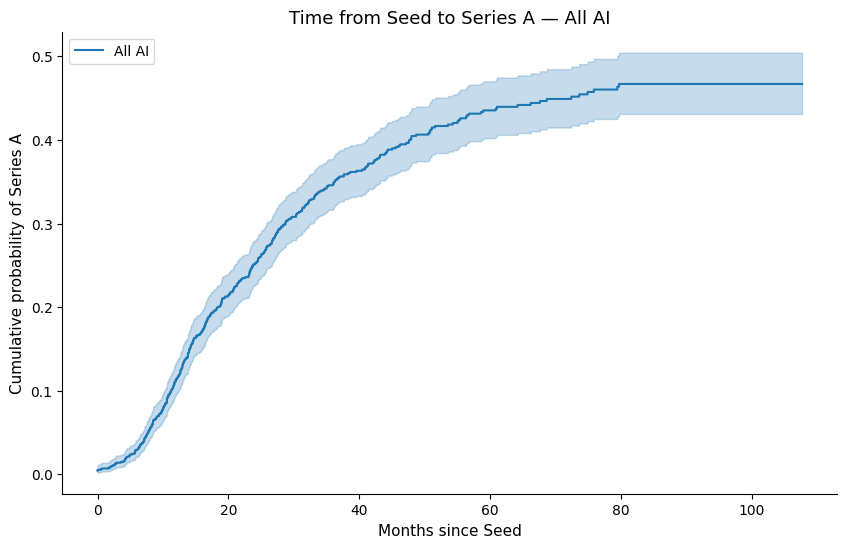

In [8]:
# Fit KM estimator on all AI startups
kmf.fit(
    durations=simple_surv_ai["time_to_series_a_months"],
    event_observed=simple_surv_ai["event_series_a"],
    label="All AI"
)

kmf.plot_cumulative_density()
plt.xlabel("Months since Seed")
plt.ylabel("Cumulative probability of Series A")
plt.title("Time from Seed to Series A — All AI")
plt.show()

### 3.3 Cross-Sector Comparison — FinTech vs. AI

Overlay both sectors on a single plot. If the curves diverge, it motivates the sector fixed effect (or sector × shock interaction) in the hazard model.

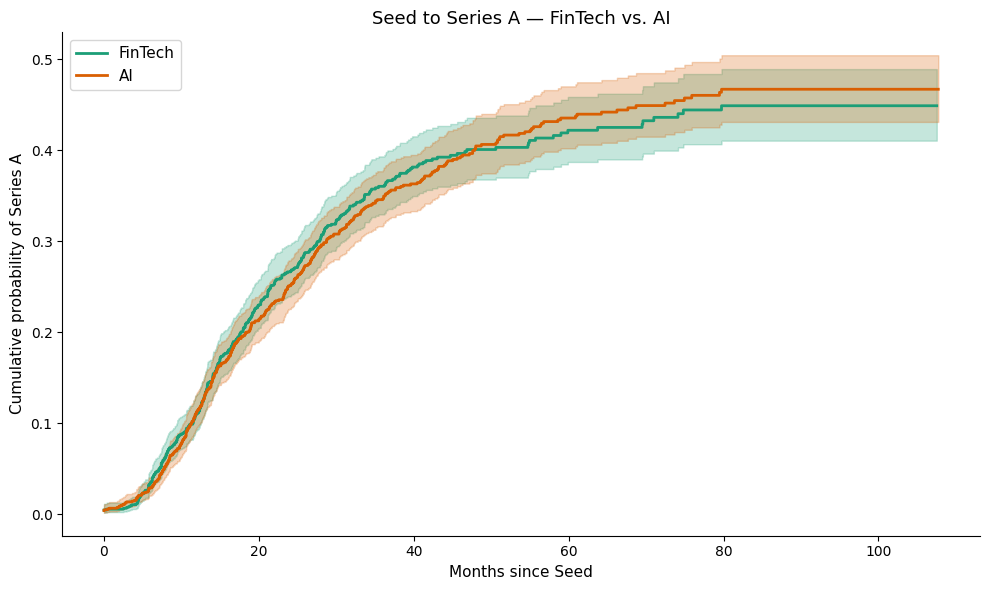

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

for label, df, color in [("FinTech", simple_surv_ft, COLORS["FinTech"]),
                          ("AI", simple_surv_ai, COLORS["AI"])]:
    kmf.fit(
        durations=df["time_to_series_a_months"],
        event_observed=df["event_series_a"],
        label=label
    )
    kmf.plot_cumulative_density(ax=ax, color=color, linewidth=2)

ax.set_xlabel("Months since Seed")
ax.set_ylabel("Cumulative probability of Series A")
ax.set_title("Seed to Series A — FinTech vs. AI")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [10]:
# Log-rank test: is the difference between FinTech and AI survival curves statistically significant?
result = logrank_test(
    simple_surv_ft["time_to_series_a_months"],
    simple_surv_ai["time_to_series_a_months"],
    event_observed_A=simple_surv_ft["event_series_a"],
    event_observed_B=simple_surv_ai["event_series_a"],
)
print("── Log-Rank Test: FinTech vs. AI ──")
print(f"  Test statistic: {result.test_statistic:.3f}")
print(f"  p-value:        {result.p_value:.4f}")
print(f"  Significant at 5%: {'Yes' if result.p_value < 0.05 else 'No'}")

── Log-Rank Test: FinTech vs. AI ──
  Test statistic: 0.002
  p-value:        0.9624
  Significant at 5%: No


---

## Part 4 — Stratified by Metro Region

### 4.1 FinTech — GNYA vs. SFBA

The original comparison from the initial analysis, preserved below.

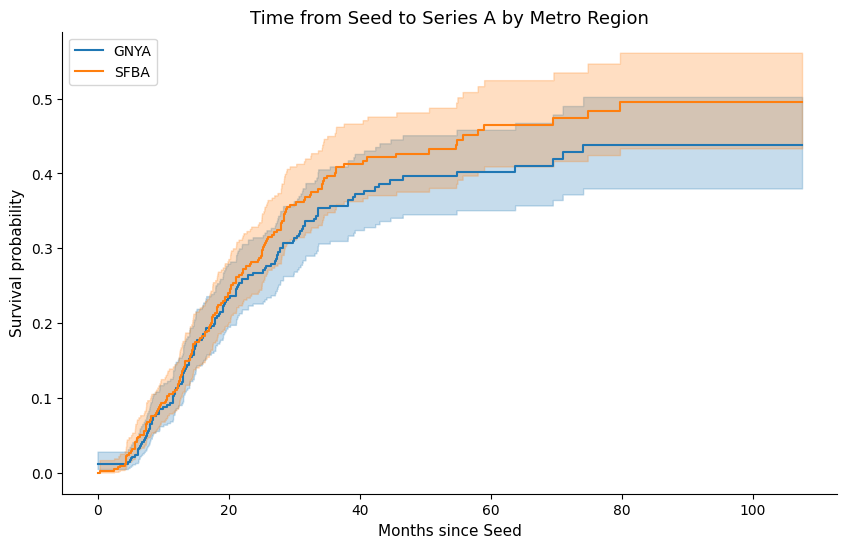

In [11]:
plt.figure()

# Stratified KM example (say GNY vs SF)
for loc in ["GNYA", "SFBA"]:
    mask = simple_surv_ft["metro_region"] == loc
    if mask.sum() == 0:
        continue

# Fit the KM model for the specific location
    kmf.fit(
        durations=simple_surv_ft.loc[mask, "time_to_series_a_months"],
        event_observed=simple_surv_ft.loc[mask, "event_series_a"],
        label=loc
    )
    kmf.plot_cumulative_density()

plt.xlabel("Months since Seed")
plt.ylabel("Survival probability")
plt.title("Time from Seed to Series A by Metro Region")
plt.legend()
plt.show()

### 4.2 All Metro Regions — Combined Dataset

Expand the comparison to all metro regions represented in the data. This motivates the metro fixed effects in the hazard model and reveals whether any region has a notably different transition profile.

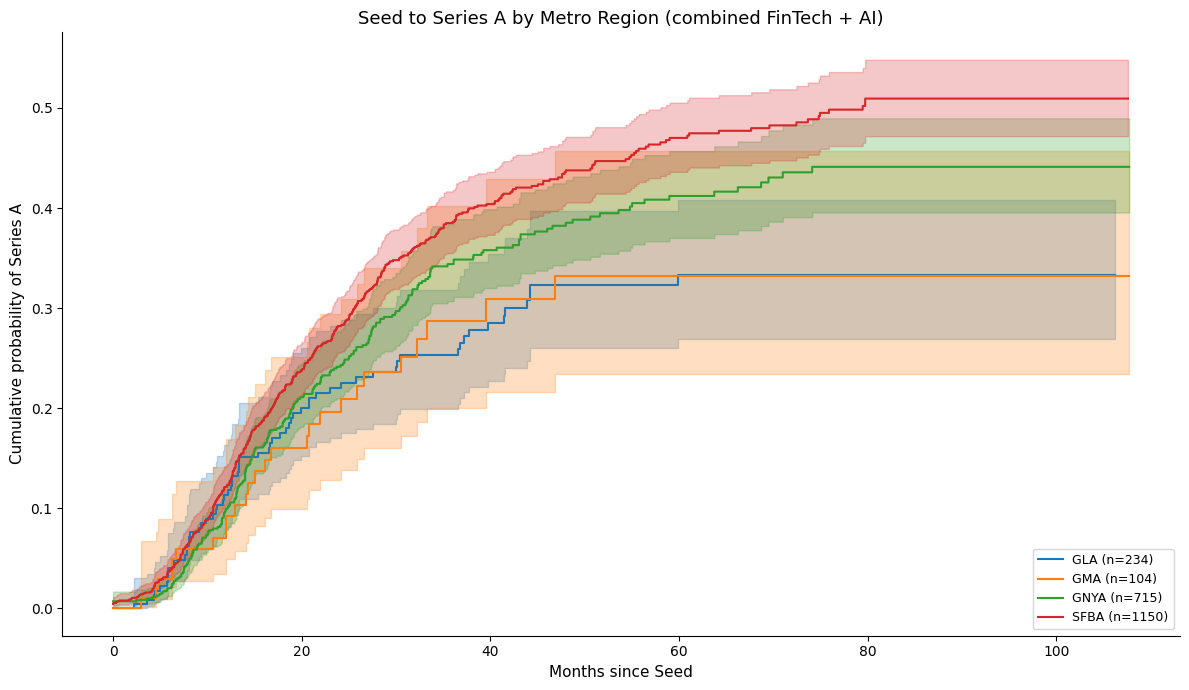

In [12]:
# Identify metro regions with sufficient sample size (≥20 firms)
metro_counts = surv["metro_region"].value_counts()
metros_to_plot = metro_counts[metro_counts >= 20].index.tolist()

fig, ax = plt.subplots(figsize=(12, 7))

for metro in sorted(metros_to_plot):
    mask = surv["metro_region"] == metro
    kmf.fit(
        durations=surv.loc[mask, "time_to_series_a_months"],
        event_observed=surv.loc[mask, "event_series_a"],
        label=f"{metro} (n={mask.sum()})"
    )
    kmf.plot_cumulative_density(ax=ax, linewidth=1.5)

ax.set_xlabel("Months since Seed")
ax.set_ylabel("Cumulative probability of Series A")
ax.set_title("Seed to Series A by Metro Region (combined FinTech + AI)")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

In [13]:
# Pairwise log-rank tests between metro regions
print("── Pairwise Log-Rank Tests (metro regions with ≥20 firms) ──")
print(f"{'Region A':>10}  vs  {'Region B':<10}  {'Statistic':>10}  {'p-value':>10}")
print("-" * 55)

tested = set()
for i, a in enumerate(sorted(metros_to_plot)):
    for b in sorted(metros_to_plot)[i+1:]:
        mask_a = surv["metro_region"] == a
        mask_b = surv["metro_region"] == b
        result = logrank_test(
            surv.loc[mask_a, "time_to_series_a_months"],
            surv.loc[mask_b, "time_to_series_a_months"],
            event_observed_A=surv.loc[mask_a, "event_series_a"],
            event_observed_B=surv.loc[mask_b, "event_series_a"],
        )
        sig = "*" if result.p_value < 0.05 else " "
        print(f"{a:>10}  vs  {b:<10}  {result.test_statistic:>10.3f}  {result.p_value:>9.4f} {sig}")

── Pairwise Log-Rank Tests (metro regions with ≥20 firms) ──
  Region A  vs  Region B     Statistic     p-value
-------------------------------------------------------
       GLA  vs  GMA              0.005     0.9424  
       GLA  vs  GNYA             3.300     0.0693  
       GLA  vs  SFBA            10.962     0.0009 *
       GMA  vs  GNYA             1.562     0.2113  
       GMA  vs  SFBA             4.830     0.0280 *
      GNYA  vs  SFBA             4.910     0.0267 *


---

## Part 5 — Stratified by Seed Cohort Year

The hazard model includes cohort-year fixed effects, implying that transition rates vary depending on when a startup received its Seed funding. This section visualizes those differences.

To keep the plot readable, cohort years are grouped into three periods that align with distinct macro regimes: pre-tightening (2016–2017), tightening cycle (2018–2019), and pandemic/post-pandemic (2020–2022).

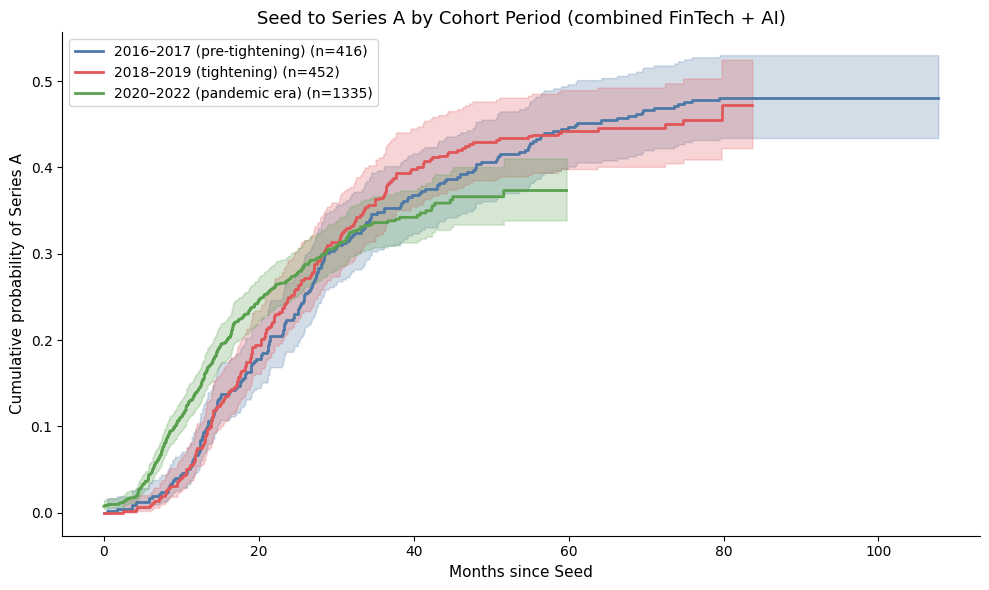

In [14]:
# Define cohort groups aligned with macro regimes
def cohort_group(year):
    if year <= 2017:
        return "2016–2017 (pre-tightening)"
    elif year <= 2019:
        return "2018–2019 (tightening)"
    else:
        return "2020–2022 (pandemic era)"

surv["cohort_group"] = surv["seed_year"].apply(cohort_group)

fig, ax = plt.subplots(figsize=(10, 6))

cohort_order = ["2016–2017 (pre-tightening)", "2018–2019 (tightening)", "2020–2022 (pandemic era)"]
cohort_colors = ["#4e79a7", "#e15759", "#59a14f"]

for group, color in zip(cohort_order, cohort_colors):
    mask = surv["cohort_group"] == group
    if mask.sum() == 0:
        continue
    kmf.fit(
        durations=surv.loc[mask, "time_to_series_a_months"],
        event_observed=surv.loc[mask, "event_series_a"],
        label=f"{group} (n={mask.sum()})"
    )
    kmf.plot_cumulative_density(ax=ax, color=color, linewidth=2)

ax.set_xlabel("Months since Seed")
ax.set_ylabel("Cumulative probability of Series A")
ax.set_title("Seed to Series A by Cohort Period (combined FinTech + AI)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [15]:
# Log-rank test: do cohort groups have significantly different survival curves?
print("── Pairwise Log-Rank Tests (cohort groups) ──")
for i, a in enumerate(cohort_order):
    for b in cohort_order[i+1:]:
        mask_a = surv["cohort_group"] == a
        mask_b = surv["cohort_group"] == b
        result = logrank_test(
            surv.loc[mask_a, "time_to_series_a_months"],
            surv.loc[mask_b, "time_to_series_a_months"],
            event_observed_A=surv.loc[mask_a, "event_series_a"],
            event_observed_B=surv.loc[mask_b, "event_series_a"],
        )
        sig = "*" if result.p_value < 0.05 else ""
        print(f"  {a}  vs  {b}")
        print(f"    Test statistic: {result.test_statistic:.3f}   p-value: {result.p_value:.4f} {sig}")
        print()

── Pairwise Log-Rank Tests (cohort groups) ──
  2016–2017 (pre-tightening)  vs  2018–2019 (tightening)
    Test statistic: 0.023   p-value: 0.8805 

  2016–2017 (pre-tightening)  vs  2020–2022 (pandemic era)
    Test statistic: 0.051   p-value: 0.8215 

  2018–2019 (tightening)  vs  2020–2022 (pandemic era)
    Test statistic: 0.634   p-value: 0.4260 



---

## Part 6 — Stratified by Monetary Policy Shock Regime

This is the key descriptive preview of the hazard model's core hypothesis. Each startup is classified based on the monetary policy shock regime prevailing in the quarter it received Seed funding: **contractionary** (shock > +1 SD), **expansionary** (shock < −1 SD), or **neutral**.

If contractionary shocks delay the Seed-to-Series A transition, the KM curve for startups seeded during contractionary quarters should lie below the others (slower transition to Series A).

In [16]:
# Load monetary policy shock data and classify quarters into regimes
shock = pd.read_csv(r"..\data\raw\macro\monetary_shock.csv")

# Parse quarter labels to timestamps
shock["date"] = shock["quarter_year"].apply(
    lambda s: pd.Period(str(s).strip().replace("-", ""), freq="Q-DEC").to_timestamp()
)

# Classify quarters by shock regime (±1 SD from mean)
mean_s = shock["mps_shock"].mean()
std_s  = shock["mps_shock"].std()

shock["regime"] = "Neutral"
shock.loc[shock["mps_shock"] > mean_s + std_s, "regime"] = "Contractionary"
shock.loc[shock["mps_shock"] < mean_s - std_s, "regime"] = "Expansionary"

print(f"Shock regime thresholds:  contractionary > {mean_s + std_s:+.4f}  |  expansionary < {mean_s - std_s:+.4f}")
print()
print(shock["regime"].value_counts().to_string())

Shock regime thresholds:  contractionary > +0.0987  |  expansionary < -0.0819

regime
Neutral           32
Contractionary     4
Expansionary       3


In [17]:
# Assign each startup a regime based on its seed quarter
surv["seed_date_parsed"] = pd.to_datetime(surv["seed_date"])
surv["seed_qstart"] = surv["seed_date_parsed"].apply(
    lambda d: pd.Timestamp(d.year, 1 + 3 * ((d.month - 1) // 3), 1)
)

# Build a quarter-to-regime mapping and merge
regime_map = shock[["date", "regime"]].rename(columns={"date": "seed_qstart"})
surv = surv.merge(regime_map, on="seed_qstart", how="left")

# Report how many startups fall into each regime
print("── Startups by seed-quarter shock regime ──")
print(surv["regime"].value_counts().to_string())

── Startups by seed-quarter shock regime ──
regime
Neutral           1497
Contractionary     276
Expansionary       178


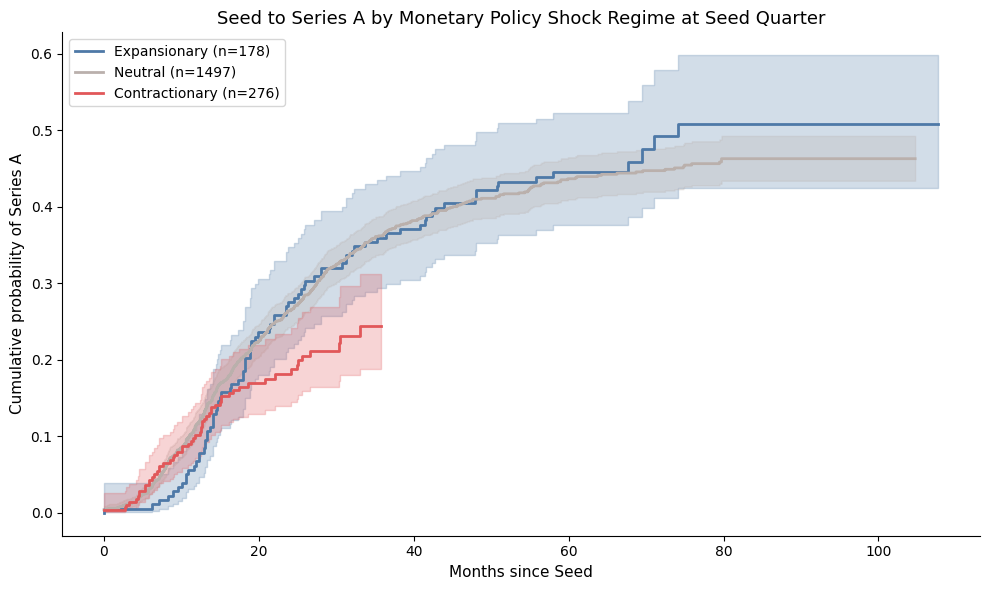

In [18]:
# KM curves stratified by monetary policy shock regime at seed quarter
fig, ax = plt.subplots(figsize=(10, 6))

regime_order = ["Expansionary", "Neutral", "Contractionary"]
regime_colors = {"Expansionary": "#4e79a7", "Neutral": "#bab0ac", "Contractionary": "#e15759"}

for regime in regime_order:
    mask = surv["regime"] == regime
    if mask.sum() < 10:
        continue
    kmf.fit(
        durations=surv.loc[mask, "time_to_series_a_months"],
        event_observed=surv.loc[mask, "event_series_a"],
        label=f"{regime} (n={mask.sum()})"
    )
    kmf.plot_cumulative_density(ax=ax, color=regime_colors[regime], linewidth=2)

ax.set_xlabel("Months since Seed")
ax.set_ylabel("Cumulative probability of Series A")
ax.set_title("Seed to Series A by Monetary Policy Shock Regime at Seed Quarter")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [19]:
# Log-rank tests across shock regimes
print("── Pairwise Log-Rank Tests (shock regimes) ──")
for i, a in enumerate(regime_order):
    for b in regime_order[i+1:]:
        mask_a = surv["regime"] == a
        mask_b = surv["regime"] == b
        if mask_a.sum() < 10 or mask_b.sum() < 10:
            print(f"  {a} vs {b}: skipped (insufficient observations)")
            continue
        result = logrank_test(
            surv.loc[mask_a, "time_to_series_a_months"],
            surv.loc[mask_b, "time_to_series_a_months"],
            event_observed_A=surv.loc[mask_a, "event_series_a"],
            event_observed_B=surv.loc[mask_b, "event_series_a"],
        )
        sig = "*" if result.p_value < 0.05 else ""
        print(f"  {a}  vs  {b}")
        print(f"    Test statistic: {result.test_statistic:.3f}   p-value: {result.p_value:.4f} {sig}")
        print()

── Pairwise Log-Rank Tests (shock regimes) ──
  Expansionary  vs  Neutral
    Test statistic: 0.082   p-value: 0.7749 

  Expansionary  vs  Contractionary
    Test statistic: 3.994   p-value: 0.0457 *

  Neutral  vs  Contractionary
    Test statistic: 7.028   p-value: 0.0080 *



---

## Part 7 — Key Takeaways

Review the results above and note the following for the hazard model in `06_discrete_time_hazard_analysis.ipynb`:

1. **Cross-sector difference** — If the FinTech vs. AI log-rank test is significant, the sector fixed effect in the hazard model is well-motivated. If not, pooling the sectors may be sufficient without sector-specific terms.

2. **Metro heterogeneity** — Metro regions with significantly different KM curves support the inclusion of metro fixed effects. Regions with very small sample sizes may need to be grouped into an "Other" category.

3. **Cohort effects** — If transition rates vary by seed cohort, cohort-year fixed effects are justified. The specific pattern (accelerating? decelerating? disrupted by COVID?) informs how to interpret the cohort dummies in the model.

4. **Shock regime preview** — This is the most important finding for the research question. If startups seeded during contractionary quarters show a delayed transition to Series A, the descriptive evidence aligns with the hazard model's hypothesis. The formal model will control for confounders and quantify the effect, but the KM curves give the intuition.

> **Next step →** Proceed to `06_discrete_time_hazard_analysis.ipynb`.